In [2]:
import gymnasium as gym
import numpy as np

class missile_interception_3d(gym.Env):
    def __init__(self, enemy_mode="ballistic"):
        assert enemy_mode in ("ballistic", "static")
        self.enemy_mode = enemy_mode

        # 1. Define Action Space: magnitude + direction on unit circle (cos, sin)
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        # 2. Define Observation Space (16D ego-frame, no actuator state)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(16,), dtype=np.float32)

        self.np_random = np.random.RandomState()
        
        # 3. Time Settings
        self.dt_act = 0.1             
        self.n_substeps = 1      
        self.dt_sim = self.dt_act / self.n_substeps 
        self.t_max = 40.0
        self.episode_cap_time = 40.0   # shorter episodes for PPO stability

        # 4. Physical Limits
        self.a_max = 350.0   # Max G-force (m/s^2) ~35G
        self.g = 9.81        
        self.collision_radius = 100.0   # easier for sparse learning

        # Small geometry so sparse RL can bootstrap (random success plausible)
        self.p_easy = 1.0                   
        self.range_min = 800.0           
        self.range_easy_max = 2500.0     
        self.range_hard_max = 2500.0

        self.targetbox_x_min = -5000
        self.targetbox_x_max = 5000
        self.targetbox_y_min = -5000
        self.targetbox_y_max = 5000

        # ---- New ZEM reward parameters ----
        self.d_scale = 100.0      # will tune later using ProNav statistics
        self.v_scale = 1000.0
        self.eta_close = 0.1

        self.r_hit_bonus = 25.0
        self.r_timeout_pen = 25.0
        self.r_enemy_ground_pen = 25.0
        self.r_def_ground_pen = 40.0

        # episode diagnostics (no thresholds)
        self.ep_dca_pos_steps = 0          # count(delta_dca > 0)
        self.ep_vclose_pos_steps = 0       # count(v_close > 0)

    def generate_enemy_missile(self):
        if self.np_random.rand() < self.p_easy:
            self.range_max_used = self.range_easy_max
        else:
            self.range_max_used = self.range_hard_max

        range_min = self.range_min
        self.attack_target_x = self.np_random.uniform(self.targetbox_x_min, self.targetbox_x_max)
        self.attack_target_y = self.np_random.uniform(self.targetbox_y_min, self.targetbox_y_max)
        self.enemy_launch_angle = self.np_random.uniform(0, 2 * np.pi)
        self.enemy_theta = self.np_random.uniform(0.523599, 1.0472) 

        self.range_max_used = max(self.range_max_used, range_min + 1.0)
        lower_limit = np.sqrt((range_min * self.g) / np.sin(2 * self.enemy_theta))
        upper_limit = np.sqrt((self.range_max_used * self.g) / np.sin(2 * self.enemy_theta))
        self.enemy_initial_velocity = self.np_random.uniform(lower_limit, upper_limit)
        self.enemy_initial_velocity = float(np.clip(self.enemy_initial_velocity, 700.0, 1100.0))

        ground_range = (
            self.enemy_initial_velocity * np.cos(self.enemy_theta)
            * (2 * self.enemy_initial_velocity * np.sin(self.enemy_theta) / self.g)
        )

        self.enemy_launch_x = self.attack_target_x + ground_range * np.cos(self.enemy_launch_angle)
        self.enemy_launch_y = self.attack_target_y + ground_range * np.sin(self.enemy_launch_angle)
        self.enemy_z = 0
        self.enemy_x = self.enemy_launch_x
        self.enemy_y = self.enemy_launch_y
        self.enemy_pos = np.array([self.enemy_x, self.enemy_y, self.enemy_z], dtype=np.float32)
        self.enemy_azimuth = (self.enemy_launch_angle + np.pi) % (2 * np.pi)

        if self.enemy_mode == "static":
            # Freeze enemy at a random mid-flight point of its ballistic trajectory
            vel0 = np.array([
                self.enemy_initial_velocity * np.cos(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_theta),
            ], dtype=np.float64)
            g_vec = np.array([0.0, 0.0, -self.g], dtype=np.float64)
            t_flight = 2.0 * self.enemy_initial_velocity * np.sin(self.enemy_theta) / self.g
            t_sample = self.np_random.uniform(0.25, 0.75) * t_flight
            pos0 = self.enemy_pos.astype(np.float64)
            self.enemy_pos = (pos0 + vel0 * t_sample + 0.5 * g_vec * (t_sample ** 2)).astype(np.float32)
            self.enemy_x, self.enemy_y, self.enemy_z = self.enemy_pos

    def generate_defense_missile(self):
        self.defense_launch_x = self.np_random.uniform(self.targetbox_x_min, self.targetbox_x_max)
        self.defense_launch_y = self.np_random.uniform(self.targetbox_y_min, self.targetbox_y_max)

        dx = self.enemy_x - self.defense_launch_x
        dy = self.enemy_y - self.defense_launch_y
        az_nominal = np.arctan2(dy, dx)
        self.az_nominal = az_nominal

        # --- Misalignment: interceptor initially points roughly toward target ---
        az_noise_deg = 5.0
        az_noise = self.np_random.uniform(-np.deg2rad(az_noise_deg), +np.deg2rad(az_noise_deg))
        self.defense_azimuth = az_nominal + az_noise

        self.defense_theta = np.deg2rad(45.0)

        base_velocity = 1200.0
        self.defense_initial_velocity = base_velocity

        self.defense_x = self.defense_launch_x
        self.defense_y = self.defense_launch_y
        self.defense_z = 0.0
        self.defense_pos = np.array([self.defense_x, self.defense_y, self.defense_z], dtype=np.float32)
    
    def _smoothstep(self, x: float) -> float:
        """Smooth ramp 0->1 with zero slope at ends, clamps outside [0,1]"""
        x = float(np.clip(x, 0.0, 1.0))
        return x * x * (3.0 - 2.0 * x)

    def _decode_action(self, a):
        """
        a = [m_raw, c_raw, s_raw] in [-1,1]^3
        Returns: (u_right, u_up) in [-1,1] with sqrt(u_right^2 + u_up^2) <= 1
        """
        a = np.asarray(a, dtype=np.float32)
        m_raw, c_raw, s_raw = float(a[0]), float(a[1]), float(a[2])

        m = 0.5 * (m_raw + 1.0)   # [-1,1] -> [0,1]

        v = np.array([c_raw, s_raw], dtype=np.float32)
        n = float(np.linalg.norm(v))
        if n < 1e-6:
            dir2 = np.array([1.0, 0.0], dtype=np.float32)
        else:
            dir2 = v / n

        u_right = float(m * dir2[0])
        u_up    = float(m * dir2[1])
        return np.array([u_right, u_up], dtype=np.float32)

    def calculate_pronav(self):
        eps = 1e-9

        # Relative geometry (use float64 for stability)
        r = (self.enemy_pos - self.defense_pos).astype(np.float64)
        v = self.defense_vel.astype(np.float64)
        vrel = (self.enemy_vel - self.defense_vel).astype(np.float64)

        R = float(np.linalg.norm(r)) + eps
        V = float(np.linalg.norm(v)) + eps

        rhat = r / R
        vhat = v / V

        # Heading error alpha = angle between velocity direction and LOS direction
        cosang = float(np.clip(np.dot(vhat, rhat), -1.0, 1.0))
        alpha = float(np.arccos(cosang))  # radians

        # LOS angular rate omega (world frame)
        omega = np.cross(r, vrel) / (float(np.dot(r, r)) + eps)
        omega_mag = float(np.linalg.norm(omega))

        # Closing speed (positive => closing)
        vc = -float(np.dot(r, vrel)) / R

        # --- PN term ---
        N = 3.0
        a_pn = N * vc * np.cross(omega, rhat)  # lateral accel in world frame

        # --- Acquisition term (turn-to-LOS) ---
        # Perpendicular component of LOS relative to forward direction
        rhat_perp = rhat - float(np.dot(rhat, vhat)) * vhat
        nperp = float(np.linalg.norm(rhat_perp))

        if nperp < 1e-8:
            a_acq = np.zeros(3, dtype=np.float64)
        else:
            rhat_perp /= nperp  # unit sideways "turn toward LOS" direction

            # Curvature-based magnitude: ~k * V^2 / R, saturate later via a_max
            k_acq = 5.0  # try 3.0–8.0
            a_acq = k_acq * (V * V / R) * rhat_perp

        # --- Blend weight w: 0 => pure PN, 1 => pure acquisition ---

        # Alpha-based weight (dominant)
        alpha_on   = np.deg2rad(20.0)   # start blending earlier
        alpha_full = np.deg2rad(55.0)

        x_alpha = (alpha - alpha_on) / (alpha_full - alpha_on + eps)
        w_alpha = self._smoothstep(x_alpha)

        # Omega-based modifier (only boosts acquisition when PN is sleepy)
        omega_full = 0.00
        omega_on   = 0.05   # <-- key: less brittle than 0.02

        x_omega = (omega_on - omega_mag) / (omega_on - omega_full + eps)
        w_omega = self._smoothstep(x_omega)

        # Robust combine: alpha dominates; omega can't fully shut it off
        w = w_alpha * (0.25 + 0.75 * w_omega)

        # Optional: if not closing, force strong acquisition
        if vc <= 0.0:
            w = max(w, 0.9)

        a_ideal = (1.0 - w) * a_pn + w * a_acq

        # Project into your lateral control basis (right/up) and normalize by a_max
        # Action is lateral body acceleration; gravity applies as world force.
        # so ProNav outputs desired NET lateral accel (same semantics as PPO)
        forward, right, up = self._compute_lateral_basis(self.defense_vel)
        a_right = float(np.dot(a_ideal, right))
        a_up    = float(np.dot(a_ideal, up))

        u_raw = np.array([a_right / self.a_max, a_up / self.a_max], dtype=np.float32)
        self._pronav_u_raw = u_raw.copy()
        u = np.clip(u_raw, -1.0, 1.0)
        return pronav_to_polar_action(float(u[0]), float(u[1]))
    
    def _segment_sphere_intersect(self, r0, r1, r_hit):
        dr = r1 - r0
        dr_norm_sq = float(np.dot(dr, dr))
        if dr_norm_sq < 1e-12:
            return float(np.dot(r0, r0)) <= r_hit * r_hit
        s_star = -float(np.dot(r0, dr)) / dr_norm_sq
        s_star = max(0.0, min(1.0, s_star))
        r_closest = r0 + s_star * dr
        return float(np.dot(r_closest, r_closest)) <= r_hit * r_hit
    
    def _get_obs(self):
        eps = 1e-9

        # World-frame relative state
        r_world = (self.enemy_pos - self.defense_pos).astype(np.float64)
        vrel_world = (self.enemy_vel - self.defense_vel).astype(np.float64)

        # Local basis from defense velocity (world frame unit vectors)
        forward, right, up = self._compute_lateral_basis(self.defense_vel)

        # ===============================
        # 1) Ego-frame (body-frame) r and vrel
        # ===============================
        r_body = np.array([
            float(np.dot(r_world, forward)),
            float(np.dot(r_world, right)),
            float(np.dot(r_world, up)),
        ], dtype=np.float64)

        vrel_body = np.array([
            float(np.dot(vrel_world, forward)),
            float(np.dot(vrel_world, right)),
            float(np.dot(vrel_world, up)),
        ], dtype=np.float64)

        # Normalize r_body / vrel_body
        pos_scale = float(self.range_easy_max)   # 10 km
        vel_scale = 2500.0                        # max vrel ~2300 m/s in Stage-1

        r_body_n = (r_body / (pos_scale + eps)).astype(np.float32)
        vrel_body_n = (vrel_body / (vel_scale + eps)).astype(np.float32)

        # ===============================
        # 2) Scalar helpers
        # ===============================
        dist = float(np.linalg.norm(r_world)) + 1e-6
        v_close = -float(np.dot(r_world, vrel_world)) / dist  # positive when closing

        dist_n = np.float32(np.clip(dist / 50_000.0, 0.0, 4.0))
        vclose_n = np.float32(np.clip(v_close / 2000.0, -2.0, 2.0))
        dist_vclose_feat = np.array([dist_n, vclose_n], dtype=np.float32)

        # Defense own vertical state (keep for ground constraint)
        def_z_n = np.float32(np.clip(self.defense_pos[2] / 15_000.0, -1.0, 2.0))
        def_vz_n = np.float32(np.clip(self.defense_vel[2] / 1200.0, -2.0, 2.0))
        def_state_feat = np.array([def_z_n, def_vz_n], dtype=np.float32)

        # ===============================
        # 4) Keep your geometry features (consistent with ego-frame)
        # ===============================
        dist_body = float(np.linalg.norm(r_body)) + 1e-6

        # LOS lateral projections in body frame
        los_right = float(r_body[1] / dist_body)
        los_up    = float(r_body[2] / dist_body)

        # LOS rate omega in body frame: omega = (r x vrel)/||r||^2
        dist2_body = float(np.dot(r_body, r_body)) + eps
        omega_body = np.cross(r_body, vrel_body) / dist2_body

        omega_right = float(omega_body[1])
        omega_up    = float(omega_body[2])

        omega_scale = 2.0
        omega_right_n = float(np.clip(omega_right / omega_scale, -2.0, 2.0))
        omega_up_n    = float(np.clip(omega_up / omega_scale, -2.0, 2.0))

        geom_feat = np.array([los_right, los_up, omega_right_n, omega_up_n], dtype=np.float32)

        # ===============================
        # 5) NEW: kinematics garnish
        # ===============================
        V_def = float(np.linalg.norm(self.defense_vel))
        V_def_n = np.float32(np.clip(V_def / 1500.0, 0.0, 3.0))
        forward_z = np.float32(float(forward[2]))               # dot(forward, world_up) since world_up=[0,0,1]

        kin_feat = np.array([V_def_n, forward_z], dtype=np.float32)

        # Final obs (16D, no actuator state)
        obs = np.concatenate(
            [r_body_n, vrel_body_n, dist_vclose_feat, def_state_feat, geom_feat, kin_feat],
            axis=0
        ).astype(np.float32)

        return obs

    def _compute_lateral_basis(self, velocity):
        """
        Horizon-stable basis:
          forward = along velocity
          right   = world_up x forward  (horizontal right)
          up      = forward x right     (completes orthonormal frame)
        This keeps 'up' as close to world-up as possible and avoids weird twisting.
        """
        speed = float(np.linalg.norm(velocity))
        if speed < 1.0:
            forward = np.array([1.0, 0.0, 0.0], dtype=np.float32)
        else:
            forward = (velocity / speed).astype(np.float32)

        world_up = np.array([0.0, 0.0, 1.0], dtype=np.float32)

        # right = world_up x forward
        right_raw = np.cross(world_up, forward)
        rnorm = float(np.linalg.norm(right_raw))

        # If forward is near world_up, right_raw ~ 0. Pick a consistent fallback.
        if rnorm < 1e-6:
            # Choose a fixed "north" axis in world XY and build right from that
            # This prevents random spinning when vertical.
            north = np.array([1.0, 0.0, 0.0], dtype=np.float32)
            right_raw = np.cross(north, forward)
            rnorm = float(np.linalg.norm(right_raw))
            if rnorm < 1e-6:
                north = np.array([0.0, 1.0, 0.0], dtype=np.float32)
                right_raw = np.cross(north, forward)
                rnorm = float(np.linalg.norm(right_raw))

        right = (right_raw / (rnorm + 1e-9)).astype(np.float32)

        # up = forward x right (not right x forward)
        up_raw = np.cross(forward, right)
        up = (up_raw / (float(np.linalg.norm(up_raw)) + 1e-9)).astype(np.float32)

        return forward, right, up

    def step(self, action):
        if getattr(self, "done", False):
            return self._get_obs(), 0.0, True, False, {"event": "called_step_after_done", "dist": float(np.linalg.norm(self.enemy_pos - self.defense_pos)), "mag_exec": float(np.nan)}
        
        action = np.clip(action, -1.0, 1.0).astype(np.float32)
        action2 = self._decode_action(action)  # 3D polar -> 2D (right, up), ||.|| <= 1
        mag_exec = float(np.linalg.norm(action2))
        assert mag_exec <= 1.0001, f"_decode_action broke invariant: ||action2|| = {mag_exec}"
        
        # Update episode trackers
        self.ep_max_action_mag = max(self.ep_max_action_mag, mag_exec)

        terminated = False
        truncated = False
        event = "running"
        
        for _ in range(self.n_substeps):
            dt = self.dt_sim
            enemy_pos_old = self.enemy_pos.copy()
            defense_pos_old = self.defense_pos.copy()
            
            forward, right, up = self._compute_lateral_basis(self.defense_vel)
            g_vec = np.array([0.0, 0.0, -self.g], dtype=np.float32)

            # Pure commanded acceleration in body right/up
            a_cmd = (action2[0] * self.a_max) * right + (action2[1] * self.a_max) * up

            # Physics: command + gravity
            self.defense_vel += (a_cmd + g_vec) * dt
            self.defense_pos += self.defense_vel * dt
            self.defense_x, self.defense_y, self.defense_z = self.defense_pos
            
            # Enemy missile: ballistic (gravity only) OR frozen (static mode)
            if self.enemy_mode == "ballistic":
                self.enemy_vel += g_vec * dt
                self.enemy_pos += self.enemy_vel * dt
                self.enemy_x, self.enemy_y, self.enemy_z = self.enemy_pos
            self.t += dt
            
            r0 = enemy_pos_old - defense_pos_old
            r1 = self.enemy_pos - self.defense_pos
            if self._segment_sphere_intersect(r0, r1, self.collision_radius):
                self.success = True
                terminated = True
                self.done = True
                event = "hit"
                self.time_to_hit = float(self.t)
                self.terminal_event = "hit"
                break
            
            # --- Only real physics terminals ---
            if self.defense_pos[2] < 0.0:
                terminated = True
                self.done = True
                event = "defense_ground"
                self.terminal_event = event
                break

            if self.enemy_mode == "ballistic" and self.enemy_pos[2] < 0.0:
                terminated = True
                self.done = True
                event = "enemy_ground"
                self.terminal_event = event
                break

            if self.enemy_mode == "static" and self.t >= self.episode_cap_time:
                truncated = True
                self.done = True
                event = "episode_cap"
                self.terminal_event = event
                break

            # --- Debug safety fuse (not a "task" terminal) ---
            if self.t >= self.t_max:
                truncated = True
                self.done = True
                event = "debug_cap"
                self.terminal_event = event
                break

        obs = self._get_obs()
        dist_after = float(np.linalg.norm(self.enemy_pos - self.defense_pos))
        self.min_dist = min(getattr(self, "min_dist", float("inf")), dist_after)
        self.ep_min_dist = min(self.ep_min_dist, float(dist_after))

        # ==========================
        # Range delta (real geometry)
        # ==========================
        if getattr(self, "prev_dist", None) is None:
            dist_prev = dist_after
        else:
            dist_prev = float(self.prev_dist)

        delta_dist = dist_prev - dist_after  # >0 means we got closer in real range
        self.prev_dist = dist_after

        # ==========================================
        # ZEM-style geometry reward (with debug)
        # ==========================================
        eps = 1e-9
        r = (self.enemy_pos - self.defense_pos).astype(np.float64)
        vrel = (self.enemy_vel - self.defense_vel).astype(np.float64)

        r_norm = float(np.linalg.norm(r)) + eps
        r_norm_sq = float(np.dot(r, r)) + eps
        vrel_norm_sq = float(np.dot(vrel, vrel)) + eps
        dot_r_v = float(np.dot(r, vrel))

        # Raw time-to-closest-approach (can be <0 or huge)
        t_star_raw = -dot_r_v / vrel_norm_sq

        # Clip horizon
        t_cap = 10.0
        t_star_clipped = float(np.clip(t_star_raw, 0.0, t_cap))

        hit_t0   = (t_star_raw <= 0.0)
        hit_tcap = (t_star_raw >= t_cap)

        # Predicted closest approach vector and distance
        r_star = r + vrel * t_star_clipped
        d_ca = float(np.linalg.norm(r_star))

        # Previous d_ca (for delta)
        if self.prev_d_ca is None:
            d_ca_prev = d_ca
        else:
            d_ca_prev = float(self.prev_d_ca)

        delta_dca = d_ca_prev - d_ca
        self.prev_d_ca = d_ca

        # Count "did d_ca improve at all?"
        if delta_dca > 0.0:
            self.ep_dca_pos_steps += 1

        self.ep_total_steps += 1

        # LOS angular rate (world)
        omega_world = np.cross(r, vrel) / r_norm_sq
        omega_mag = float(np.linalg.norm(omega_world))

        # Closing speed (positive is closing)
        v_close = -dot_r_v / r_norm

        # Count "are we closing at all?"
        if v_close > 0.0:
            self.ep_vclose_pos_steps += 1

        if t_star_clipped < 2.0:
            self.ep_omega_terminal_samples.append(omega_mag)

        # ======================================
        # SPARSE TERMINAL REWARD ONLY (hit=+1, else=0)
        # No penalties — maximize P(hit)
        # ======================================
        reward = 1.0 if event == "hit" else 0.0

        if terminated or truncated:
            self.terminal_event = event

        steps = self.ep_total_steps
        dca_pos_ratio = (self.ep_dca_pos_steps / steps) if steps > 0 else 0.0
        vclose_pos_ratio = (self.ep_vclose_pos_steps / steps) if steps > 0 else 0.0

        v_def = self.defense_vel.astype(np.float64)
        V_def = float(np.linalg.norm(v_def)) + 1e-9
        fwd_z = float(self._compute_lateral_basis(self.defense_vel)[0][2])

        info = {
            "event": event,
            "t": float(self.t),
            "dist": float(dist_after),
            "closing": float(v_close),
            "reward": float(reward),
            "mag_exec": float(mag_exec),
            "defense_z": float(self.defense_pos[2]),
            "defense_vz": float(self.defense_vel[2]),
            "defense_speed": float(V_def),
            "forward_z": float(fwd_z),
            "delta_dca": float(delta_dca),
            "dca_pos_steps": int(self.ep_dca_pos_steps),
            "dca_pos_ratio": float(dca_pos_ratio),
            "vclose_pos_steps": int(self.ep_vclose_pos_steps),
            "vclose_pos_ratio": float(vclose_pos_ratio),
            "d_ca": float(d_ca),
            "t_star": float(t_star_clipped),
        }
        info.update({
            "dist_prev": float(dist_prev),
            "delta_dist": float(delta_dist),
            "t_cap": float(t_cap),
            "t_star_raw": float(t_star_raw),
            "t_star_hit0": bool(hit_t0),
            "t_star_hitcap": bool(hit_tcap),
            "dot_r_vrel": float(dot_r_v),
            "vrel_norm_sq": float(vrel_norm_sq),
            "r_norm": float(r_norm),
            "omega_mag": float(omega_mag),
            "r_star_x": float(r_star[0]),
            "r_star_y": float(r_star[1]),
            "r_star_z": float(r_star[2]),
        })
        if terminated or truncated:
            d_min = float(self.ep_min_dist)
            hit = (event == "hit")
            info["hit"] = hit
            info["miss_distance"] = d_min
            info["min_dist"] = d_min
            info["max_action_mag"] = float(self.ep_max_action_mag)
            info["time_to_hit"] = float(self.time_to_hit) if self.time_to_hit is not None else np.nan
            info["los_terminal_p95"] = float(np.percentile(self.ep_omega_terminal_samples, 95)) if self.ep_omega_terminal_samples else np.nan
        return obs, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None: self.np_random = np.random.RandomState(seed)
        self.done = False
        self.success = False
        self.t = 0.0
        self.generate_enemy_missile()
        self.generate_defense_missile()
        
        self.defense_vel = np.array([
            self.defense_initial_velocity * np.cos(self.defense_azimuth) * np.cos(self.defense_theta),
            self.defense_initial_velocity * np.sin(self.defense_azimuth) * np.cos(self.defense_theta),
            self.defense_initial_velocity * np.sin(self.defense_theta)
        ], dtype=np.float32)
        
        if self.enemy_mode == "ballistic":
            self.enemy_vel = np.array([
                self.enemy_initial_velocity * np.cos(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_theta)
            ], dtype=np.float32)
        else:
            self.enemy_vel = np.zeros(3, dtype=np.float32)
        
        self.defense_pos = np.array([self.defense_x, self.defense_y, self.defense_z], dtype=np.float32)

        # enemy_pos: ballistic = rebuild from launch coords; static = keep mid-flight sample from generate_enemy_missile
        if self.enemy_mode == "ballistic":
            self.enemy_pos = np.array([self.enemy_x, self.enemy_y, self.enemy_z], dtype=np.float32)
        else:
            self.enemy_x, self.enemy_y, self.enemy_z = self.enemy_pos

        d0 = float(np.linalg.norm(self.enemy_pos - self.defense_pos))
        Vd = float(np.linalg.norm(self.defense_vel)) + 1e-6
        if self.enemy_mode == "static":
            self.t_max = self.episode_cap_time
        else:
            self.t_max = min(40.0, 3.0 * d0 / Vd)
        self.min_dist = d0
        self.ep_min_dist = d0
        self.ep_max_action_mag = 0.0
        self.time_to_hit = None
        self.terminal_event = "running"
        self.prev_d_ca = None
        self.prev_dist = None
        self.ep_dca_pos_steps = 0
        self.ep_vclose_pos_steps = 0
        self.ep_total_steps = 0
        self.ep_omega_terminal_samples = []
        
        return self._get_obs(), {}


def pronav_to_polar_action(u_right, u_up):
    """Convert old-style 2D (right, up) action to new 3D polar (m_raw, c_raw, s_raw)."""
    u = np.array([u_right, u_up], dtype=np.float32)
    m = float(np.linalg.norm(u))
    if m < 1e-6:
        return np.array([-1.0, 1.0, 0.0], dtype=np.float32)  # magnitude 0, arbitrary direction
    dir2 = u / m
    m = min(m, 1.0)
    m_raw = 2.0 * m - 1.0  # [0,1] -> [-1,1]
    return np.array([m_raw, float(dir2[0]), float(dir2[1])], dtype=np.float32)


# ==========================================
# EVALUATION FUNCTION (separate from training reward)
# ==========================================
def evaluate_policy(env, policy_fn, n_episodes=100, seed0=0):
    """
    Evaluate a policy and return episode-level metrics.
    This is separate from training reward - these metrics are what you actually care about.
    
    Args:
        env: missile_interception_3d environment instance
        policy_fn: Function that takes obs and returns action
        n_episodes: Number of episodes to evaluate
        seed0: Starting seed (episodes use seed0, seed0+1, ..., seed0+n_episodes-1)
    
    Returns:
        summary: Dict with aggregated metrics (hit_rate, min_dist stats, etc.)
        metrics: Dict with raw episode data
    """
    metrics = {
        "hits": 0,
        "ground_defense": 0,
        "ground_enemy": 0,
        "episode_cap": 0,
        "debug_cap": 0,
        "min_dist_list": [],
        "time_to_hit_list": [],
        "max_g_list": [],
        "dca_pos_ratio_list": [],
        "vclose_pos_ratio_list": [],
        "los_terminal_p95_list": [],
    }

    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + i)
        done = False

        while not done:
            action = policy_fn(obs)  # your PPO policy OR env.calculate_pronav() baseline
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        event = info["event"]
        metrics["min_dist_list"].append(env.ep_min_dist)
        metrics["max_g_list"].append(env.ep_max_action_mag)
        metrics["dca_pos_ratio_list"].append(info["dca_pos_ratio"])
        metrics["vclose_pos_ratio_list"].append(info["vclose_pos_ratio"])
        if "los_terminal_p95" in info and np.isfinite(info.get("los_terminal_p95", np.nan)):
            metrics["los_terminal_p95_list"].append(info["los_terminal_p95"])

        if event == "hit":
            metrics["hits"] += 1
            if env.time_to_hit is not None:
                metrics["time_to_hit_list"].append(env.time_to_hit)
        elif event == "defense_ground":
            metrics["ground_defense"] += 1
        elif event == "enemy_ground":
            metrics["ground_enemy"] += 1
        elif event == "episode_cap":
            metrics["episode_cap"] += 1
        elif event == "debug_cap":
            metrics["debug_cap"] += 1

    hit_rate = metrics["hits"] / n_episodes

    summary = {
        "hit_rate": hit_rate,
        "min_dist_mean": float(np.mean(metrics["min_dist_list"])),
        "min_dist_p50": float(np.median(metrics["min_dist_list"])),
        "min_dist_p10": float(np.percentile(metrics["min_dist_list"], 10)),
        "time_to_hit_mean": float(np.mean(metrics["time_to_hit_list"])) if metrics["time_to_hit_list"] else None,
        "max_g_mean": float(np.mean(metrics["max_g_list"])),
        "dca_pos_ratio_mean": float(np.mean(metrics["dca_pos_ratio_list"])),
        "vclose_pos_ratio_mean": float(np.mean(metrics["vclose_pos_ratio_list"])),
        "los_terminal_p95_mean": float(np.mean(metrics["los_terminal_p95_list"])) if metrics["los_terminal_p95_list"] else np.nan,
        "violations": {
            "defense_ground": metrics["ground_defense"],
            "enemy_ground": metrics["ground_enemy"],
            "episode_cap": metrics["episode_cap"],
            "debug_cap": metrics["debug_cap"],
        }
    }
    return summary, metrics

def run_baseline(n_episodes=20, seed0=0):
    env = missile_interception_3d(enemy_mode="static")
    policy_fn = lambda obs: env.calculate_pronav()

    min_dist_list = []
    dca_pos_list = []
    vclose_pos_list = []
    los_terminal_p95_list = []
    hits = 0

    print(f"Running {n_episodes} episodes of Augmented ProNav...\n")

    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + i)
        done = False
        while not done:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        event = info["event"]
        min_dist_list.append(env.ep_min_dist)
        dca_pos_list.append(info["dca_pos_ratio"])
        vclose_pos_list.append(info["vclose_pos_ratio"])
        if "los_terminal_p95" in info and np.isfinite(info.get("los_terminal_p95", np.nan)):
            los_terminal_p95_list.append(info["los_terminal_p95"])
        if event == "hit":
            hits += 1

        print(f"Ep {i+1:02d} | {event:<14} | minD {env.ep_min_dist:6.1f}m | dca_pos {info['dca_pos_ratio']:.3f} | vclose_pos {info['vclose_pos_ratio']:.3f} | los_p95 {info.get('los_terminal_p95', np.nan):.4f}")

    min_dist_list = np.array(min_dist_list)
    dca_pos_list = np.array(dca_pos_list)
    vclose_pos_list = np.array(vclose_pos_list)

    print(f"\n--- SUMMARY ({n_episodes} eps) ---")
    print(f"Hit Rate:            {hits}/{n_episodes} ({hits/n_episodes*100:.1f}%)")
    print(f"min_dist mean:       {float(np.mean(min_dist_list)):.1f} m")
    print(f"min_dist p50:        {float(np.median(min_dist_list)):.1f} m")
    print(f"min_dist p10:        {float(np.percentile(min_dist_list, 10)):.1f} m")
    print(f"dca_pos_ratio_mean:  {float(np.mean(dca_pos_list)):.3f}")
    print(f"vclose_pos_ratio_mean: {float(np.mean(vclose_pos_list)):.3f}")
    if los_terminal_p95_list:
        print(f"los_terminal_p95_mean: {float(np.mean(los_terminal_p95_list)):.4f}")

if __name__ == "__main__":
    run_baseline()

Running 20 episodes of Augmented ProNav...

Ep 01 | hit            | minD    6.1m | dca_pos 0.879 | vclose_pos 0.996 | los_p95 0.0076
Ep 02 | hit            | minD    8.4m | dca_pos 0.907 | vclose_pos 1.000 | los_p95 0.0095
Ep 03 | hit            | minD   94.7m | dca_pos 0.958 | vclose_pos 1.000 | los_p95 0.0078
Ep 04 | hit            | minD   35.7m | dca_pos 0.911 | vclose_pos 1.000 | los_p95 0.0072
Ep 05 | hit            | minD   44.7m | dca_pos 0.991 | vclose_pos 1.000 | los_p95 0.0065
Ep 06 | hit            | minD   23.9m | dca_pos 0.889 | vclose_pos 1.000 | los_p95 0.0073
Ep 07 | hit            | minD   44.8m | dca_pos 0.907 | vclose_pos 1.000 | los_p95 0.0073
Ep 08 | hit            | minD   65.1m | dca_pos 0.996 | vclose_pos 1.000 | los_p95 0.0060
Ep 09 | hit            | minD   60.2m | dca_pos 0.894 | vclose_pos 1.000 | los_p95 0.0071
Ep 10 | hit            | minD   76.9m | dca_pos 0.898 | vclose_pos 1.000 | los_p95 0.0075
Ep 11 | hit            | minD   17.1m | dca_pos 0.891 | 

In [3]:
import os
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


class HitLogger(BaseCallback):
    def _on_step(self):
        infos = self.locals.get("infos", [])
        for info in infos:
            if "hit" in info:
                if info["hit"]:
                    print("HIT")
                else:
                    print("MISS")

                if self.logger is not None:
                    for key in ("min_dist", "dca_pos_ratio", "vclose_pos_ratio"):
                        if key in info and np.isfinite(info[key]):
                            self.logger.record(
                                f"rollout/{key}",
                                float(info[key]),
                                exclude="stdout",
                            )
        return True


log_dir = "./ppo_missile_tensorboard/"
os.makedirs(log_dir, exist_ok=True)


vec_env = DummyVecEnv([
    lambda: Monitor(
        missile_interception_3d(enemy_mode="static"),
        info_keywords=("min_dist", "dca_pos_ratio", "vclose_pos_ratio")
    )
])


# --------------------------------
# LOAD EXISTING MODEL
# --------------------------------

model = PPO.load(
    "ppo_missile_radius200_13M",
    env=vec_env,
    tensorboard_log=log_dir
)


# --------------------------------
# CONTINUE TRAINING
# --------------------------------

model.learn(
    total_timesteps=2_000_000,
    tb_log_name="ppo_radius100_finetune",
    callback=HitLogger()
)


# --------------------------------
# SAVE NEW MODEL
# --------------------------------

model.save("ppo_missile_radius100_15M")

Logging to ./ppo_missile_tensorboard/ppo_radius100_finetune_1
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 254      |
|    ep_rew_mean     | 1        |
| time/              |          |
|    fps             | 637      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 4096     |
---------------------------------
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
HIT
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 237          |
|    ep_rew_mean          | 1            |
| time/                   |              |
|    fps                  | 630          |
|    iterations           | 2            |
|    time_elapsed         | 12           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.00

In [4]:
# ==========================================
# LOAD TRAINED POLICY
# ==========================================

from stable_baselines3 import PPO

model = PPO.load("ppo_missile_radius100_15M")

# deterministic policy (no exploration noise)
policy_fn = lambda obs: model.predict(obs, deterministic=True)[0]


# ==========================================
# RUN EVALUATION
# ==========================================

eval_env = missile_interception_3d(enemy_mode="static")

summary, metrics = evaluate_policy(
    eval_env,
    policy_fn,
    n_episodes=100,
    seed0=0
)

print("\n===== PPO EVALUATION =====")
for k, v in summary.items():
    print(f"{k}: {v}")


===== PPO EVALUATION =====
hit_rate: 1.0
min_dist_mean: 42.95076455116272
min_dist_p50: 34.54595184326172
min_dist_p10: 8.09340558052063
time_to_hit_mean: 22.81600000000006
max_g_mean: 1.0000000810623169
dca_pos_ratio_mean: 0.7812965081665938
vclose_pos_ratio_mean: 0.9989072190233014
los_terminal_p95_mean: 0.6607078774420495
violations: {'defense_ground': 0, 'enemy_ground': 0, 'episode_cap': 0, 'debug_cap': 0}


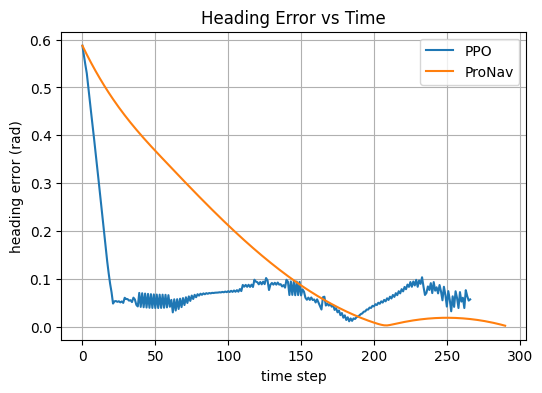

In [5]:
# ==========================================
# HEADING ERROR DIAGNOSTIC
# ==========================================
import matplotlib.pyplot as plt

def compute_heading_error(enemy_path, defense_path, defense_vel_path):
    eps = 1e-9
    errors = []

    for i in range(len(enemy_path)-1):

        r = enemy_path[i] - defense_path[i]
        v = defense_vel_path[i]

        r_norm = np.linalg.norm(r) + eps
        v_norm = np.linalg.norm(v) + eps

        cosang = np.clip(np.dot(v, r) / (r_norm * v_norm), -1.0, 1.0)
        theta = np.arccos(cosang)

        errors.append(theta)

    return np.array(errors)


def rollout_with_vel(env, policy_fn, seed=0):

    obs, _ = env.reset(seed=seed)

    enemy_path = []
    defense_path = []
    defense_vel_path = []

    done = False

    while not done:

        enemy_path.append(env.enemy_pos.copy())
        defense_path.append(env.defense_pos.copy())
        defense_vel_path.append(env.defense_vel.copy())

        action = policy_fn(obs)
        obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

    return (
        np.array(enemy_path),
        np.array(defense_path),
        np.array(defense_vel_path),
    )


# PPO rollout
ppo_env = missile_interception_3d(enemy_mode="static")
enemy, defense, vel = rollout_with_vel(
    ppo_env,
    lambda obs: model.predict(obs, deterministic=True)[0],
    seed=42
)

ppo_heading = compute_heading_error(enemy, defense, vel)

# ProNav rollout
pn_env = missile_interception_3d(enemy_mode="static")
enemy_pn, defense_pn, vel_pn = rollout_with_vel(
    pn_env,
    lambda obs: pn_env.calculate_pronav(),
    seed=42
)

pn_heading = compute_heading_error(enemy_pn, defense_pn, vel_pn)


plt.figure(figsize=(6,4))
plt.plot(ppo_heading, label="PPO")
plt.plot(pn_heading, label="ProNav")
plt.xlabel("time step")
plt.ylabel("heading error (rad)")
plt.title("Heading Error vs Time")
plt.grid()
plt.legend()
plt.show()